# Most-Popular Baseline Model

The simplest possible recommender: rank candidate articles by how many times they were clicked in the training set.

This serves as a lower-bound benchmark â€” any smarter model should beat it.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import roc_auc_score

TRAIN_BEHAVIORS = "../smallDataset/MINDsmall_train/behaviors.tsv"
DEV_BEHAVIORS   = "../smallDataset/MINDsmall_dev/behaviors.tsv"

COLS = ["impression_id", "user_id", "time", "history", "impressions"]

## Step 1 â€” Build popularity scores from training data

For each article, count how many times it was clicked across all training impressions.
This is the popularity score we will use to rank candidates.

In [3]:
train = pd.read_csv(TRAIN_BEHAVIORS, sep="\t", header=None, names=COLS)

click_counts = Counter()

for imp in train["impressions"]:
    for item in imp.split():
        nid, label = item.rsplit("-", 1)
        if label == "1":
            click_counts[nid] += 1

print(f"Unique articles with at least 1 click: {len(click_counts)}")
print(f"Total clicks recorded: {sum(click_counts.values())}")

Unique articles with at least 1 click: 7713
Total clicks recorded: 236344


**What this tells us:**

Out of all the articles in the training set, 7,713 were clicked at least once. 
The rest were shown to users but ignored — they get a popularity score of 0 and will always be ranked last by this model. 
This is the cold-start problem: new or unpopular articles have no signal and the model cannot help them.

## Step 2 â€” Inspect the popularity distribution

Most articles are rarely clicked; a handful are clicked very often.
This long-tail distribution is typical of news datasets.

count    7713.000000
mean       30.642292
std       136.413297
min         1.000000
25%         1.000000
50%         2.000000
75%        14.000000
max      4316.000000
dtype: float64


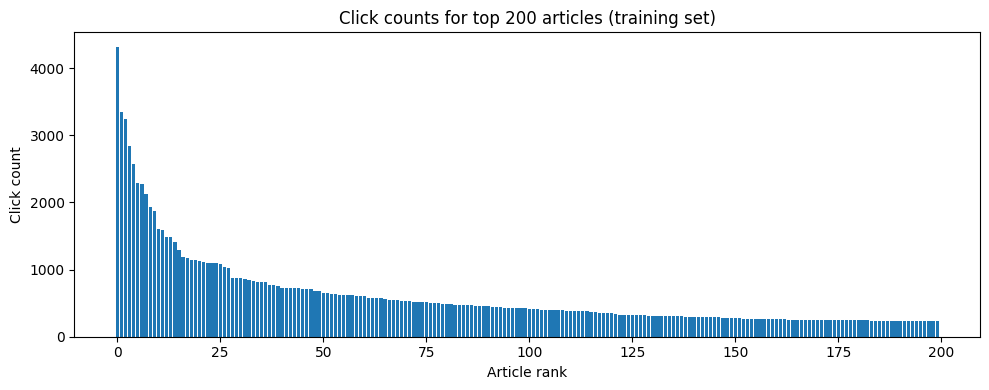


Top 185 articles (2.4%) account for 50% of all clicks


In [4]:
counts = pd.Series(click_counts).sort_values(ascending=False)

print(counts.describe())

plt.figure(figsize=(10, 4))
counts.values[:200].tolist()
plt.bar(range(200), counts.values[:200])
plt.title("Click counts for top 200 articles (training set)")
plt.xlabel("Article rank")
plt.ylabel("Click count")
plt.tight_layout()
plt.show()

# What fraction of articles account for 50% of all clicks?
total = counts.sum()
cumulative = counts.cumsum()
n_50 = (cumulative <= total * 0.5).sum()
print(f"\nTop {n_50} articles ({100*n_50/len(counts):.1f}%) account for 50% of all clicks")

**What this tells us:**

The popularity distribution is extremely skewed (mean=30, median=2). 
This means a tiny group of viral articles dominate — the top 2.4% of articles account for half of all clicks. 
The chart shows this visually: a steep drop-off after the first few articles.

For the recommender this means: the model will confidently rank a handful of mega-popular articles to the top for *every* user, 
regardless of their personal interests. That is why this is a weak baseline.

## Step 3 â€” Define the scoring function

For each impression the scorer receives a list of candidate article IDs and returns a score for each.
Articles not seen in training get a score of 0 (cold-start articles).

In [5]:
def popularity_score(history: list, candidates: list) -> list:
    """Return training click count for each candidate (0 if unseen)."""
    return [click_counts.get(nid, 0) for nid in candidates]

## Step 4 â€” Evaluation

We evaluate on the dev set using four standard MIND metrics:

- **AUC** â€” how well scores separate clicked from non-clicked articles
- **MRR** â€” mean reciprocal rank of the first relevant result
- **nDCG@5** â€” normalised discounted cumulative gain at rank 5
- **nDCG@10** â€” same at rank 10

In [6]:
def dcg_at_k(relevance, k):
    relevance = np.array(relevance[:k], dtype=np.float32)
    if relevance.size == 0:
        return 0.0
    return float((relevance / np.log2(np.arange(2, relevance.size + 2))).sum())

def ndcg_at_k(relevance, k):
    ideal = sorted(relevance, reverse=True)
    idcg = dcg_at_k(ideal, k)
    return dcg_at_k(relevance, k) / idcg if idcg > 0 else 0.0

def mrr(relevance):
    for i, r in enumerate(relevance):
        if r == 1:
            return 1.0 / (i + 1)
    return 0.0

def evaluate(behaviors_path, score_fn):
    aucs, mrrs, ndcg5s, ndcg10s = [], [], [], []
    skipped = 0

    with open(behaviors_path, encoding="utf-8") as f:
        for line in f:
            cols = line.strip().split("\t")
            if len(cols) < 5:
                continue

            history    = cols[3].strip().split() if cols[3].strip() else []
            impressions = cols[4].strip().split()

            candidates, labels = [], []
            for imp in impressions:
                parts = imp.rsplit("-", 1)
                if len(parts) != 2:
                    continue
                nid, label = parts
                candidates.append(nid)
                labels.append(int(label))

            # AUC is undefined when all labels are 0 or all are 1
            if sum(labels) == 0 or sum(labels) == len(labels):
                skipped += 1
                continue

            scores = score_fn(history, candidates)
            ranked = [lbl for _, lbl in sorted(zip(scores, labels), reverse=True)]

            aucs.append(roc_auc_score(labels, scores))
            mrrs.append(mrr(ranked))
            ndcg5s.append(ndcg_at_k(ranked, 5))
            ndcg10s.append(ndcg_at_k(ranked, 10))

    print(f"Evaluated {len(aucs)} impressions | Skipped (degenerate): {skipped}")
    return {
        "AUC":     round(float(np.mean(aucs)), 4),
        "MRR":     round(float(np.mean(mrrs)), 4),
        "nDCG@5":  round(float(np.mean(ndcg5s)), 4),
        "nDCG@10": round(float(np.mean(ndcg10s)), 4),
    }

In [7]:
metrics = evaluate(DEV_BEHAVIORS, popularity_score)

print("\nMost-Popular Baseline â€” Dev Set Results")
print("-" * 40)
for k, v in metrics.items():
    print(f"  {k:<10} {v}")

Evaluated 73152 impressions | Skipped (degenerate): 0

Most-Popular Baseline â€” Dev Set Results
----------------------------------------
  AUC        0.5318
  MRR        0.3387
  nDCG@5     0.3321
  nDCG@10    0.3982


**What these numbers mean:**

- **AUC 0.5318** — AUC measures how often the model ranks a clicked article above a non-clicked one. 
0.5 is pure random guessing, 1.0 is perfect. We got 0.53 — barely better than a coin flip. 
This makes sense: we are recommending the same popular articles to everyone, ignoring who the user actually is.

- **MRR 0.3387** — On average, the first relevant (clicked) article appears around position 3 (1/0.34 ≈ 3). 
Higher is better; 1.0 would mean the clicked article is always ranked #1.

- **nDCG@5 0.3321** — Of the top 5 articles we recommend, how well are the relevant ones ranked? 
1.0 is perfect, 0 is useless. 0.33 means we are doing something, but leaving a lot on the table.

- **nDCG@10 0.3982** — Same idea but looking at the top 10. It is higher than nDCG@5 because with more slots 
there is more chance of including the clicked article somewhere in the list.

**Bottom line:** these numbers are your baseline. Any model that actually looks at the user's reading history 
should beat all four of these.

## Step 5 Reflect on the results

A few things to note about this baseline:

- It uses **no user information** â€” every user gets the same ranking
- It completely ignores the **cold-start problem**: articles not seen in training get score 0, so they will always be ranked last regardless of their actual relevance
- It assumes **global popularity is a proxy for relevance**, which is a reasonable but weak signal
- Any personalised model should comfortably beat these numbers on AUC, MRR and nDCG